In [6]:
import numpy as np
import pandas as pd
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt

from check_warmup import avg_warmup_count, plot_avg_warmup_count

from environment import GLMBandit

from glmbanditexp.algorithms.ecolog import EcoLog
from glmbanditexp.algorithms.gloc import Gloc
from glmbanditexp.algorithms.glm_ucb import GlmUCB
from glmbanditexp.algorithms.rs_glinucb import RS_GLinUCB
from glmbanditexp.algorithms.private_rs_glinucb import Private_RS_GLinUCB
from glmbanditexp.algorithms.ofulogplus import OFULogPlus

# Import simulation utilities
from simulation_utils import simulate_with_epsilon, plot_regret


In [7]:
num_trials = 10
d=5
K=10
T=5000
kappa=50.0
R=1.0
S=5.0
lmbda=20.0
seed=186329


Running trial 1


100%|██████████| 5000/5000 [00:00<00:00, 17603.85it/s]


Running trial 2


100%|██████████| 5000/5000 [00:00<00:00, 15654.50it/s]


Running trial 3


...

100%|██████████| 5000/5000 [00:00<00:00, 17741.58it/s]


Running trial 9


100%|██████████| 5000/5000 [00:00<00:00, 17872.67it/s]


Running trial 10


100%|██████████| 5000/5000 [00:00<00:00, 17333.48it/s]


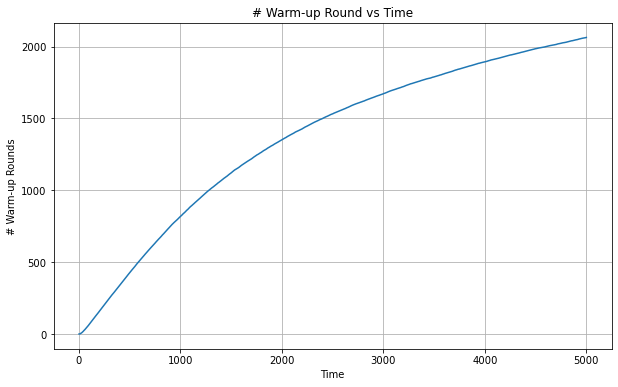

In [8]:
count = avg_warmup_count(num_trials, d, K, T, kappa, R, S, lmbda, seed)
plot_avg_warmup_count(count, show_flag=True)


In [9]:
config = {"full_norm": True}
config['seed'] = 109832
config['model'] = 'Probit'
config['theta_dim'] = 3
config['num_arms'] = 20
config['theta_norm'] = 2.0
config['horizon_length'] = 5000

env = GLMBandit(config=config)
print('Kappa =', env.kappa)
print('Theta =' , env.theta)



Calculating kappa...


100%|██████████| 5000/5000 [00:00<00:00, 49682.01it/s]


Calculating kappa star...


100%|██████████| 5000/5000 [00:00<00:00, 30647.97it/s]


Kappa = 18.393669911451706
Theta = [0.29541604 1.82659084 0.75914113]


In [10]:
algo_names_list = ['RS-GLinUCB', 'GLM-UCB', 'GLOC', 'Private-GLM']
num_trials = 1

regret_dict = simulate_with_epsilon(num_trials, env, algo_names_list, 0.02, epsilon_arr = [4, 6,8], seed=109832)
with open('./Results/Extras_probit/experiment_probit_uniform_split_S_2_0.pickle', 'wb') as f:
    pickle.dump(regret_dict, f)
plot_regret(regret_dict, env.T, './Results/Extras_probit/Probit_Regret_S_2_0.png')



Simulating trial 1
Lambda is  31.084898755419616 for non-private glinucb
Lambda: 232.80627249253132 private rs glinucb
Count1 cutoff: 3, Count2 cutoff: 8
Lambda: 165.56581458016075 private rs glinucb
Count1 cutoff: 3, Count2 cutoff: 9
Lambda: 131.94558562397546 private rs glinucb
Count1 cutoff: 3, Count2 cutoff: 9
Algorithm mapping:
  Index 0: RS-GLinUCB (Sawarni et al. 2024)
  Index 1: GLM-UCB (Filippi et al. 2010)
  Index 2: GLOC (Jun et al. 2017)
  Index 3: Private-GLM (This work) -> ε=4
  Index 4: Private-GLM (This work) -> ε=6
  Index 5: Private-GLM (This work) -> ε=8


  3%|▎         | 173/5000 [00:02<01:22, 58.48it/s]

Counter 2 switching at 173 for non-private RS-glinucb


  8%|▊         | 401/5000 [00:05<00:55, 82.60it/s]

Counter 2 switching at 389 for non-private RS-glinucb


...

 78%|███████▊  | 3906/5000 [06:35<00:30, 35.96it/s]  

Counter 2 switching at 3902 for non-private RS-glinucb


100%|██████████| 5000/5000 [10:55<00:00,  7.63it/s]  

Max logdet curr H: 18.338477947750977, Max logdet prev H: 18.185075685593258 epsilon 4 delta 0.02
Counter1 final: 0, Counter2 final: 3 epsilon 4 delta 0.02
Max logdet curr H: 17.847338212510508, Max logdet prev H: 17.202240283270225 epsilon 6 delta 0.02
Counter1 final: 0, Counter2 final: 3 epsilon 6 delta 0.02
Max logdet curr H: 17.422027460569858, Max logdet prev H: 17.2059283198768 epsilon 8 delta 0.02
Counter1 final: 0, Counter2 final: 4 epsilon 8 delta 0.02


FileNotFoundError: [Errno 2] No such file or directory: './Results/Extras_probit/experiment_probit_uniform_split_S_2_0.pickle'

In [13]:
config = {"full_norm": True}
config['seed'] = 109832
config['model'] = 'Probit'
config['theta_dim'] = 3
config['num_arms'] = 20
config['theta_norm'] = 2.5
config['horizon_length'] = 5000

env = GLMBandit(config=config)
print('Kappa =', env.kappa)
print('Theta =' , env.theta)


Calculating kappa...


100%|██████████| 5000/5000 [00:00<00:00, 49265.46it/s]


Calculating kappa star...


100%|██████████| 5000/5000 [00:00<00:00, 53318.55it/s]


Kappa = 56.43600574575181
Theta = [0.36927006 2.28323855 0.94892641]


Simulating trial 1
Lambda is  31.084898755419616 for non-private glinucb
Lambda: 232.80627248969603 private rs glinucb
Count1 cutoff: 16, Count2 cutoff: 8
Lambda: 165.5658145782706 private rs glinucb
Count1 cutoff: 16, Count2 cutoff: 9
Lambda: 131.94558562255781 private rs glinucb
Count1 cutoff: 16, Count2 cutoff: 9
Algorithm mapping:
  Index 0: RS-GLinUCB (Sawarni et al. 2024)
  Index 1: GLM-UCB (Filippi et al. 2010)
  Index 2: GLOC (Jun et al. 2017)
  Index 3: Private-GLM (This work) -> ε=4
  Index 4: Private-GLM (This work) -> ε=6
  Index 5: Private-GLM (This work) -> ε=8


  4%|▎         | 184/5000 [00:02<01:11, 67.81it/s]

Counter 2 switching at 173 for non-private RS-glinucb


  8%|▊         | 420/5000 [00:06<01:04, 70.50it/s]

Counter 2 switching at 410 for non-private RS-glinucb


...

Counter 2 switching at 3007 for non-private RS-glinucb


 80%|████████  | 4021/5000 [07:20<00:26, 36.28it/s]  

Counter 2 switching at 4015 for non-private RS-glinucb


100%|██████████| 5000/5000 [11:32<00:00,  7.22it/s]  


Max logdet curr H: 18.334469391836944, Max logdet prev H: 18.18125319180229 epsilon 4 delta 0.02
Counter1 final: 0, Counter2 final: 3 epsilon 4 delta 0.02
Max logdet curr H: 17.838771107288327, Max logdet prev H: 17.196492329783318 epsilon 6 delta 0.02
Counter1 final: 0, Counter2 final: 3 epsilon 6 delta 0.02
Max logdet curr H: 17.411003815496468, Max logdet prev H: 17.197423377547008 epsilon 8 delta 0.02
Counter1 final: 0, Counter2 final: 4 epsilon 8 delta 0.02


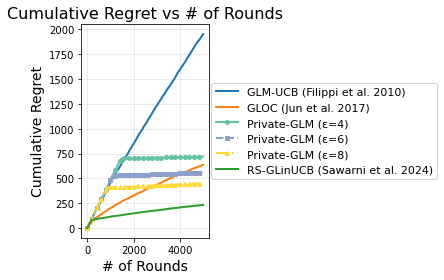

In [15]:
algo_names_list = ['RS-GLinUCB', 'GLM-UCB', 'GLOC', 'Private-GLM']
num_trials = 1

regret_dict = simulate_with_epsilon(num_trials, env, algo_names_list, 0.02, epsilon_arr = [4, 6,8], seed=109832)
with open('./Results/Extras_probit/experiment_probit_uniform_split_S_2_5.pickle', 'wb') as f:
    pickle.dump(regret_dict, f)
plot_regret(regret_dict, env.T, './Results/Extras_probit/Probit_Regret_S_2_5.png')


In [16]:
config = {"full_norm": True}
config['seed'] = 109832
config['model'] = 'Probit'
config['theta_dim'] = 3
config['num_arms'] = 20
config['theta_norm'] = 3.0
config['horizon_length'] = 5000

env = GLMBandit(config=config)
print('Kappa =', env.kappa)
print('Theta =' , env.theta)


Calculating kappa...


100%|██████████| 5000/5000 [00:00<00:00, 46797.95it/s]


Calculating kappa star...


100%|██████████| 5000/5000 [00:00<00:00, 48704.94it/s]


Kappa = 222.147513394731
Theta = [0.44312407 2.73988626 1.13871169]


Simulating trial 1
Lambda is  31.084898755419616 for non-private glinucb
Lambda: 232.80627248623063 private rs glinucb
Count1 cutoff: 95, Count2 cutoff: 8
Lambda: 165.56581457596025 private rs glinucb
Count1 cutoff: 95, Count2 cutoff: 9
Lambda: 131.9455856208251 private rs glinucb
Count1 cutoff: 95, Count2 cutoff: 9
Algorithm mapping:
  Index 0: RS-GLinUCB (Sawarni et al. 2024)
  Index 1: GLM-UCB (Filippi et al. 2010)
  Index 2: GLOC (Jun et al. 2017)
  Index 3: Private-GLM (This work) -> ε=4
  Index 4: Private-GLM (This work) -> ε=6
  Index 5: Private-GLM (This work) -> ε=8


  0%|          | 0/5000 [00:00<?, ?it/s]/Users/sahasrajitsarmasarkar/Downloads/AiStats_appendix/Code/glmbanditexp/utils/utils.py:373: RuntimeWarning: divide by zero encountered in log
  return - np.sum(Y * np.log(probit(np.dot(X, theta))) + (1 - Y) * np.log(1 - probit(np.dot(X, theta)))) + lmbda * np.sum(np.square(theta))
/Users/sahasrajitsarmasarkar/Downloads/AiStats_appendix/Code/glmbanditexp/utils/utils.py:373: RuntimeWarning: invalid value encountered in multiply
  return - np.sum(Y * np.log(probit(np.dot(X, theta))) + (1 - Y) * np.log(1 - probit(np.dot(X, theta)))) + lmbda * np.sum(np.square(theta))
 35%|███▌      | 1769/5000 [00:32<00:56, 57.14it/s]

Counter 2 switching at 1761 for non-private RS-glinucb


 98%|█████████▊| 4920/5000 [11:45<00:02, 27.12it/s]  

Counter 2 switching at 4917 for non-private RS-glinucb


100%|██████████| 5000/5000 [11:48<00:00,  7.06it/s]


Max logdet curr H: 18.33180340504845, Max logdet prev H: 18.17860858819785 epsilon 4 delta 0.02
Counter1 final: 0, Counter2 final: 3 epsilon 4 delta 0.02
Max logdet curr H: 17.833737348475296, Max logdet prev H: 17.193813343353344 epsilon 6 delta 0.02
Counter1 final: 0, Counter2 final: 3 epsilon 6 delta 0.02
Max logdet curr H: 17.408155280874723, Max logdet prev H: 17.194299840704723 epsilon 8 delta 0.02
Counter1 final: 0, Counter2 final: 4 epsilon 8 delta 0.02


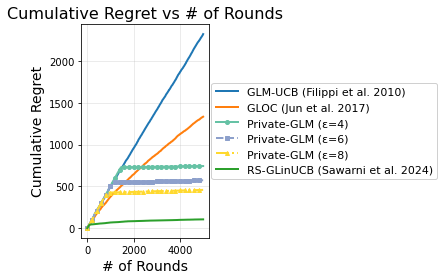

In [17]:
algo_names_list = ['RS-GLinUCB', 'GLM-UCB', 'GLOC', 'Private-GLM']
num_trials = 1

regret_dict = simulate_with_epsilon(num_trials, env, algo_names_list, 0.02, epsilon_arr = [4, 6,8], seed=109832)
with open('./Results/Extras_probit/experiment_probit_uniform_split_S_3_0.pickle', 'wb') as f:
    pickle.dump(regret_dict, f)
plot_regret(regret_dict, env.T, './Results/Extras_probit/Probit_Regret_S_3_0.png')


In [10]:
config = {"full_norm": True}
config['seed'] = 109832
config['model'] = 'Probit'
config['theta_dim'] = 3
config['num_arms'] = 10
config['theta_norm'] = 3.25
config['horizon_length'] = 5000

env = GLMBandit(config=config)
print('Kappa =', env.kappa)
print('Theta =' , env.theta)


Calculating kappa...


100%|██████████| 5000/5000 [00:00<00:00, 57381.54it/s]


Calculating kappa star...


100%|██████████| 5000/5000 [00:00<00:00, 51402.30it/s]


Kappa = 477.96532802718076
Theta = [0.48005107 2.96821012 1.23360434]


Simulating trial 1
Lambda is  31.084898755419616 for non-private glinucb
Lambda: 232.80627128854383 private rs glinucb
Count1 cutoff: 240, Count2 cutoff: 2
Lambda: 165.5658137775024 private rs glinucb
Count1 cutoff: 240, Count2 cutoff: 3
Lambda: 131.94558502198174 private rs glinucb
Count1 cutoff: 240, Count2 cutoff: 3
Algorithm mapping:
  Index 0: RS-GLinUCB (Sawarni et al. 2024) (legacy-switch, MLE)
  Index 1: GLM-UCB (Filippi et al. 2010)
  Index 2: GLOC (Jun et al. 2017)
  Index 3: Private-GLM (This work) -> ε=4
  Index 4: Private-GLM (This work) -> ε=6
  Index 5: Private-GLM (This work) -> ε=8


  0%|          | 2/5000 [00:00<05:54, 14.09it/s]/Users/sahasrajitsarmasarkar/Downloads/AiStats_appendix/Code/glmbanditexp/utils/utils.py:373: RuntimeWarning: divide by zero encountered in log
  return - np.sum(Y * np.log(probit(np.dot(X, theta))) + (1 - Y) * np.log(1 - probit(np.dot(X, theta)))) + lmbda * np.sum(np.square(theta))
/Users/sahasrajitsarmasarkar/Downloads/AiStats_appendix/Code/glmbanditexp/utils/utils.py:373: RuntimeWarning: invalid value encountered in multiply
  return - np.sum(Y * np.log(probit(np.dot(X, theta))) + (1 - Y) * np.log(1 - probit(np.dot(X, theta)))) + lmbda * np.sum(np.square(theta))
 30%|██▉       | 1498/5000 [01:04<02:36, 22.31it/s]

Counter 2 switching at 1497 for non-private RS-glinucb


 59%|█████▉    | 2966/5000 [03:32<3:30:08,  6.20s/it]

Counter2: 2 == 2, crossing at 2962 epsilon 4 delta 0.02


...

Counter 2 switching at 1101 for non-private RS-glinucb


 62%|██████▏   | 3106/5000 [04:09<4:37:42,  8.80s/it]

Counter2: 2 == 2, crossing at 3102 epsilon 4 delta 0.02


100%|██████████| 5000/5000 [06:31<00:00, 12.77it/s]  

Max logdet curr H: 18.24236597643778, Max logdet prev H: 17.74781401781163 epsilon 4 delta 0.02
Counter1 final: 0, Counter2 final: 2 epsilon 4 delta 0.02
Max logdet curr H: 15.659063168133615, Max logdet prev H: 15.328106346294415 epsilon 6 delta 0.02
Counter1 final: 80, Counter2 final: 0 epsilon 6 delta 0.02
Max logdet curr H: 15.05596860130886, Max logdet prev H: 14.647168808737018 epsilon 8 delta 0.02
Counter1 final: 161, Counter2 final: 0 epsilon 8 delta 0.02


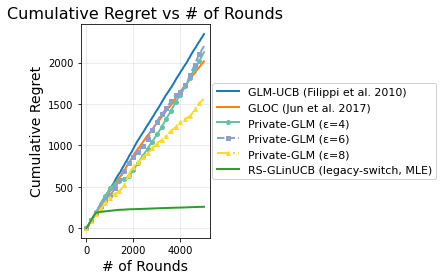

In [11]:
algo_names_list = ['RS-GLinUCB', 'GLM-UCB', 'GLOC', 'Private-GLM']
num_trials = 5

regret_dict = simulate_with_epsilon(num_trials, env, algo_names_list, 0.02, epsilon_arr = [4, 6,8], seed=109832)
with open('./Results/Extras_probit/experiment_probit_uniform_split_S_3_25.pickle', 'wb') as f:
    pickle.dump(regret_dict, f)
plot_regret(regret_dict, env.T, './Results/Extras_probit/Probit_Regret_S_3_25.png')


In [22]:
config = {"full_norm": True}
config['seed'] = 109832
config['model'] = 'Probit'
config['theta_dim'] = 3
config['num_arms'] = 10
config['theta_norm'] = 3.5
config['horizon_length'] = 5000

env = GLMBandit(config=config)
print('Kappa =', env.kappa)
print('Theta =' , env.theta)


Calculating kappa...


100%|██████████| 5000/5000 [00:00<00:00, 63546.79it/s]


Calculating kappa star...


100%|██████████| 5000/5000 [00:00<00:00, 63981.06it/s]


Kappa = 1105.8741582644873
Theta = [0.51697808 3.19653397 1.32849698]


In [24]:
algo_names_list = ['RS-GLinUCB', 'GLM-UCB', 'GLOC', 'Private-GLM']
num_trials = 1

regret_dict = simulate_with_epsilon(num_trials, env, algo_names_list, 0.02, epsilon_arr = [4, 6,8], seed=109832)
with open('./Results/Extras_probit/experiment_probit_uniform_split_S_3_5.pickle', 'wb') as f:
    pickle.dump(regret_dict, f)
plot_regret(regret_dict, env.T, './Results/Extras_probit/Probit_Regret_S_3_5.png')


Simulating trial 1
Lambda is  31.084898755419616 for non-private glinucb
Lambda: 232.8062710953855 private rs glinucb
Count1 cutoff: 645, Count2 cutoff: 8
Lambda: 165.56581364873023 private rs glinucb
Count1 cutoff: 645, Count2 cutoff: 9
Lambda: 131.94558492540256 private rs glinucb
Count1 cutoff: 645, Count2 cutoff: 9
Algorithm mapping:
  Index 0: RS-GLinUCB (Sawarni et al. 2024)
  Index 1: GLM-UCB (Filippi et al. 2010)
  Index 2: GLOC (Jun et al. 2017)
  Index 3: Private-GLM (This work) -> ε=4
  Index 4: Private-GLM (This work) -> ε=6
  Index 5: Private-GLM (This work) -> ε=8


 12%|█▏        | 619/5000 [10:42<1:15:47,  1.04s/it]


KeyboardInterrupt: 

##Table to generate the cumulative regret

In [2]:
import pickle
import numpy as np
import pandas as pd
from environment import GLMBandit

# S values to include (skip 3.25)
S_values = [2.0, 2.5, 3.0]

results = {}
kappa_values = {}

# Compute kappa for each S using the probit environment
for S in S_values:
    config = {"full_norm": True}
    config["seed"] = 109832
    config["model"] = "Probit"
    config["theta_dim"] = 3
    config["num_arms"] = 20
    config["theta_norm"] = S
    config["horizon_length"] = 5000

    env = GLMBandit(config=config)
    kappa_values[S] = env.kappa

    # Load corresponding regret pickle
    s_str = str(S).replace(".", "_")
    fname = f"./Results/Extras_probit_mod/experiment_probit_uniform_split_S_{s_str}.pickle"
    with open(fname, "rb") as f:
        regret_dict = pickle.load(f)

    # Sum (cumulative) regret per algorithm
    cumulative = {}
    for algo_name, regret_arr in regret_dict.items():
        if hasattr(regret_arr, "tolist"):
            cumulative_regret = np.sum(regret_arr)
        else:
            cumulative_regret = np.sum(np.array(regret_arr))
        cumulative[algo_name] = cumulative_regret

    results[S] = cumulative

# Optional: pretty mapping to match paper notation
# algo_label_map = {
#     "GLM-UCB (Filippi et al. 2010)": "GLM-UCB [FCGS10]",
#     "GLOC (Jun et al. 2017)": "GLOC [JBNW17]",
#     "RS-GLinUCB (Sawarni et al. 2024)": "RS-GLinUCB [SDBS24]",
#     # Private-GLM labels are already descriptive; keep as-is
# }

algo_label_map = {
"GLM-UCB (Filippi et al. 2010)": "GLM-UCB [FCGS10]",
"GLOC (Jun et al. 2017)": "GLOC [JBNW17]",
"ECOLog (Faury et al. 2022)": "ECOLog [Faury22]",
"RS-GLinUCB": "RS-GLinUCB [SDBS24]",
}

# Fixed row order for the table
alg_order = [
    "GLM-UCB [FCGS10]",
    "ECOLog [Faury22]",
    "GLOC [JBNW17]",
    "Private-GLM (ε=4)",
    "Private-GLM (ε=6)",
    "Private-GLM (ε=8)",
    "RS-GLinUCB [SDBS24]",
]

# Build DataFrame: rows = algorithms, cols = S (Kappa)
cols = [f"S = {S} (Kappa = {kappa_values[S]:.2f})" for S in S_values]
table = pd.DataFrame(index=alg_order, columns=cols, dtype=float)

for S in S_values:
    for raw_name, cum_regret in results[S].items():
        label = algo_label_map.get(raw_name, raw_name)
        if label in table.index:
            table.loc[label, f"S = {S} (Kappa = {kappa_values[S]:.2f})"] = cum_regret

display(table.round(2))

Calculating kappa...


100%|██████████| 5000/5000 [00:00<00:00, 56144.44it/s]


Calculating kappa star...


100%|██████████| 5000/5000 [00:00<00:00, 58106.37it/s]


Calculating kappa...


...

Calculating kappa...


100%|██████████| 5000/5000 [00:00<00:00, 58364.95it/s]


Calculating kappa star...


100%|██████████| 5000/5000 [00:00<00:00, 59050.09it/s]


,S = 2.0 (Kappa = 18.39),S = 2.5 (Kappa = 56.44),S = 3.0 (Kappa = 222.15)
GLM-UCB [FCGS10],1400.27,1943.23,2323.06
ECOLog [Faury22],NaN,NaN,NaN
GLOC [JBNW17],384.68,631.60,1346.59
Private-GLM (ε=4),674.17,721.26,744.35
Private-GLM (ε=6),516.58,546.97,559.04
Private-GLM (ε=8),425.53,445.27,452.60
RS-GLinUCB [SDBS24],289.69,170.10,200.62


In [20]:
regret_dict.keys()

dict_keys(['RS-GLinUCB', 'GLM-UCB (Filippi et al. 2010)', 'GLOC (Jun et al. 2017)', 'Private-GLM (ε=4)', 'Private-GLM (ε=6)', 'Private-GLM (ε=8)'])